In [1]:
# Diagnóstico do ambiente e pacotes
import sys
import site
print('Python:', sys.executable)
print('Site-packages:', site.getsitepackages())
import pandas; print('pandas:', pandas.__version__)
import numpy; print('numpy:', numpy.__version__)
import matplotlib; print('matplotlib:', matplotlib.__version__)
import seaborn; print('seaborn:', seaborn.__version__)
try:
    import ta
    print('ta importado com sucesso!')
except Exception as e:
    print('ta não instalado:', e)

Python: c:\Users\JC INFO\Desktop\SSD-SUPORTE QUANTITATIVO\co-piloto-quant\vbt_env\Scripts\python.exe
Site-packages: ['c:\\Users\\JC INFO\\Desktop\\SSD-SUPORTE QUANTITATIVO\\co-piloto-quant\\vbt_env', 'c:\\Users\\JC INFO\\Desktop\\SSD-SUPORTE QUANTITATIVO\\co-piloto-quant\\vbt_env\\Lib\\site-packages']
pandas: 3.0.1
numpy: 2.4.2
matplotlib: 3.10.8
seaborn: 0.13.2
ta importado com sucesso!


In [26]:
# Rodar análise em múltiplos ativos automaticamente
import glob

# Caminho dos arquivos de features
arquivos = glob.glob('../../co-piloto-quant/src/co_piloto_quant/data/features/*_enriched.parquet_features.parquet')

In [27]:
# Ajuste dos pontos de exaustão para 60, 55, 45 e 40, e análise de pullback de baixa
import pandas as pd
pontos = [60, 55, 45, 40]
resultados_pontos = []

for arquivo in arquivos:
    try:
        df = pd.read_parquet(arquivo)
        if 'rsi_120' not in df.columns or 'close' not in df.columns:
            continue
        df = df.sort_index()
        nome_ativo = arquivo.split('/')[-1].split('_')[0]
        # Repouso entre 52-48 vindo de cima e de baixo
        mask_repouso = (df['rsi_120'] <= 52) & (df['rsi_120'] >= 48)
        mask_antes_cima = df['rsi_120'].shift(1) > 52
        mask_antes_baixo = df['rsi_120'].shift(1) < 48
        repouso_cima = mask_repouso & mask_antes_cima
        repouso_baixo = mask_repouso & mask_antes_baixo
        retornos_cima = []
        retornos_baixo = []
        for idx in df[repouso_cima].index:
            if idx + 5 < len(df):
                ret = (df.loc[idx+5, 'close'] - df.loc[idx, 'close']) / df.loc[idx, 'close']
                retornos_cima.append(ret)
        for idx in df[repouso_baixo].index:
            if idx + 5 < len(df):
                ret = (df.loc[idx+5, 'close'] - df.loc[idx, 'close']) / df.loc[idx, 'close']
                retornos_baixo.append(ret)
        # Eventos de exaustão para múltiplos pontos
        def prob_subida(indices, dias=5):
            subidas = 0
            total = 0
            for idx in df[indices].index:
                if idx + dias < len(df):
                    ret = (df.loc[idx+dias, 'close'] - df.loc[idx, 'close']) / df.loc[idx, 'close']
                    if ret > 0: subidas += 1
                    total += 1
            return subidas / total if total > 0 else np.nan
        ponto_result = {'ativo': nome_ativo,
                        'repouso_cima_qtd': repouso_cima.sum(),
                        'repouso_cima_ret': np.mean(retornos_cima) if retornos_cima else np.nan,
                        'repouso_baixo_qtd': repouso_baixo.sum(),
                        'repouso_baixo_ret': np.mean(retornos_baixo) if retornos_baixo else np.nan}
        for p in pontos:
            up = (df['rsi_120'] >= p) & (df['rsi_120'].shift(1) < p)
            down = (df['rsi_120'] <= p) & (df['rsi_120'].shift(1) > p)
            ponto_result[f'prob_alta_{p}_up'] = prob_subida(up)
            ponto_result[f'prob_alta_{p}_down'] = prob_subida(down)
        resultados_pontos.append(ponto_result)
    except Exception as e:
        print(f'Erro no ativo {arquivo}: {e}')

resultados_df = pd.DataFrame(resultados_pontos)
display(resultados_df)


""


# Análise do IFR (Índice de Força Relativa) e Estratégia TPM

Este notebook explora o uso do IFR (RSI) e a aplicação da estratégia TPM (Tendência, Padrão, Momento) em séries temporais financeiras.

---

**Seções:**
1. Importação das Bibliotecas Necessárias
2. Carregamento dos Dados de Preços
3. Cálculo do Índice de Força Relativa (IFR/RSI)
4. Implementação da Estratégia TPM
5. Visualização dos Resultados
6. Backtest da Estratégia
7. Avaliação de Performance

In [28]:
# 1. Importação das Bibliotecas Necessárias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from ta.momentum import RSIIndicator

plt.style.use('seaborn-v0_8-darkgrid')

## 2. Carregamento dos Dados de Preços

Carregue aqui os dados históricos do ativo desejado. Exemplo com arquivo Parquet:

In [62]:
# Carregue aqui o ativo desejado (exemplo: ITUB4 ou PETR4)
from ta.momentum import RSIIndicator

# Escolha o ticker do ativo
TICKER = 'ASAI3_SA'  # Altere para testar outro ativo, ex: 'PETR4_SA'

# Carrega o arquivo do ativo selecionado
df = pd.read_parquet(f'../../co-piloto-quant/src/co_piloto_quant/data/features/{TICKER}_enriched.parquet_features.parquet')
df = df.sort_index()
# Garante que a coluna rsi_120 existe
if 'rsi_120' not in df.columns:
    rsi = RSIIndicator(close=df['close'], window=120)
    df['rsi_120'] = rsi.rsi()
# Exibe apenas as colunas disponíveis
colunas = [c for c in ['close', 'rsi_120', 'regime_rolling'] if c in df.columns]
if colunas:
    display(df[colunas].tail())
else:
    print('Nenhuma das colunas close, rsi_120 ou regime_rolling está presente no DataFrame.')

,close,rsi_120
date,,
2026-02-26,9.45,51.283059
2026-02-27,9.34,51.040187
2026-03-02,9.25,50.841528
2026-03-03,8.65,49.545127
2026-03-04,8.36,48.936938


## 3. Cálculo do Índice de Força Relativa (IFR/RSI)

Se necessário, recalcule o IFR 120 a partir dos preços de fechamento:

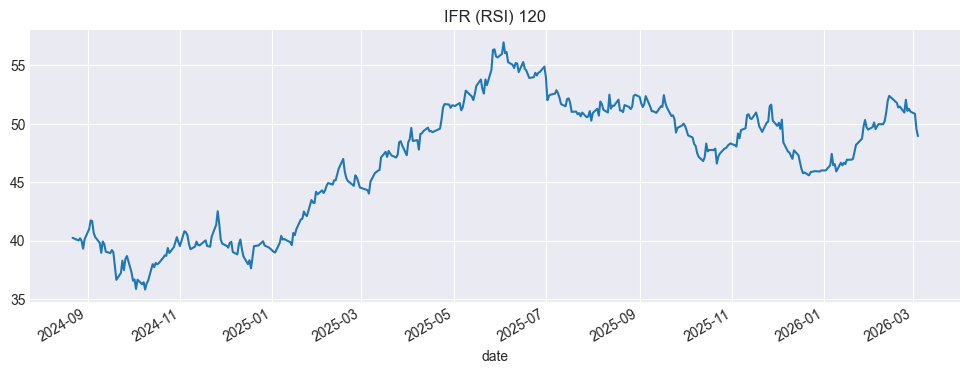

In [63]:
# Se a coluna 'rsi_120' não existir, calcule:
try:
    df
except NameError:
    raise RuntimeError("O DataFrame 'df' não está definido. Execute a célula de carregamento de dados antes desta.")

if 'rsi_120' not in df.columns:
    rsi = RSIIndicator(close=df['close'], window=120)
    df['rsi_120'] = rsi.rsi()

import matplotlib.pyplot as plt
df['rsi_120'].plot(figsize=(12,4), title='IFR (RSI) 120')
plt.show()

## 4. Implementação da Estratégia TPM (Tendência, Padrão, Momento)

Exemplo de regras simples usando IFR 120:

In [64]:
# Sinal de compra: IFR entra na faixa 48-52 vindo de cima (pullback em tendência de alta)
# Sinal de venda: IFR entra na faixa 48-52 vindo de baixo (pullback em tendência de baixa)
faixa_pullback = (df['rsi_120'] >= 48) & (df['rsi_120'] <= 52)
compra_pullback = faixa_pullback & (df['rsi_120'].shift(1) > 52)
venda_pullback = faixa_pullback & (df['rsi_120'].shift(1) < 48)

# NOVAS REGRAS: Entrada por exaustão nos extremos
compra_45 = (df['rsi_120'] <= 45) & (df['rsi_120'].shift(1) > 45)  # Compra ao cruzar 45 para baixo
venda_55 = (df['rsi_120'] >= 55) & (df['rsi_120'].shift(1) < 55)  # Venda ao cruzar 55 para cima

df['sinal_compra'] = compra_pullback | compra_45
# Stop da compra em 50
stop_compra = (df['rsi_120'] >= 50) & (df['rsi_120'].shift(1) < 50)

df['sinal_venda'] = venda_pullback | venda_55
# Stop da venda em 50
stop_venda = (df['rsi_120'] <= 50) & (df['rsi_120'].shift(1) > 50)

print(f'Qtd sinais de compra (pullback de cima ou cruzou 45): {df["sinal_compra"].sum()}')
print(f'Qtd sinais de venda (pullback de baixo ou cruzou 55): {df["sinal_venda"].sum()}')
df[['rsi_120', 'sinal_compra', 'sinal_venda']].tail(10)

Qtd sinais de compra (pullback de cima ou cruzou 45): 11
Qtd sinais de venda (pullback de baixo ou cruzou 55): 9


,rsi_120,sinal_compra,sinal_venda
date,,,
2026-02-19,51.382478,False,False
2026-02-20,51.467735,False,False
2026-02-23,50.949673,False,False
2026-02-24,52.050059,False,False
2026-02-25,51.094241,True,False
2026-02-26,51.283059,False,False
2026-02-27,51.040187,False,False
2026-03-02,50.841528,False,False
2026-03-03,49.545127,False,False


## 5. Visualização dos Resultados

Gráfico dos preços, IFR e sinais de compra/venda:

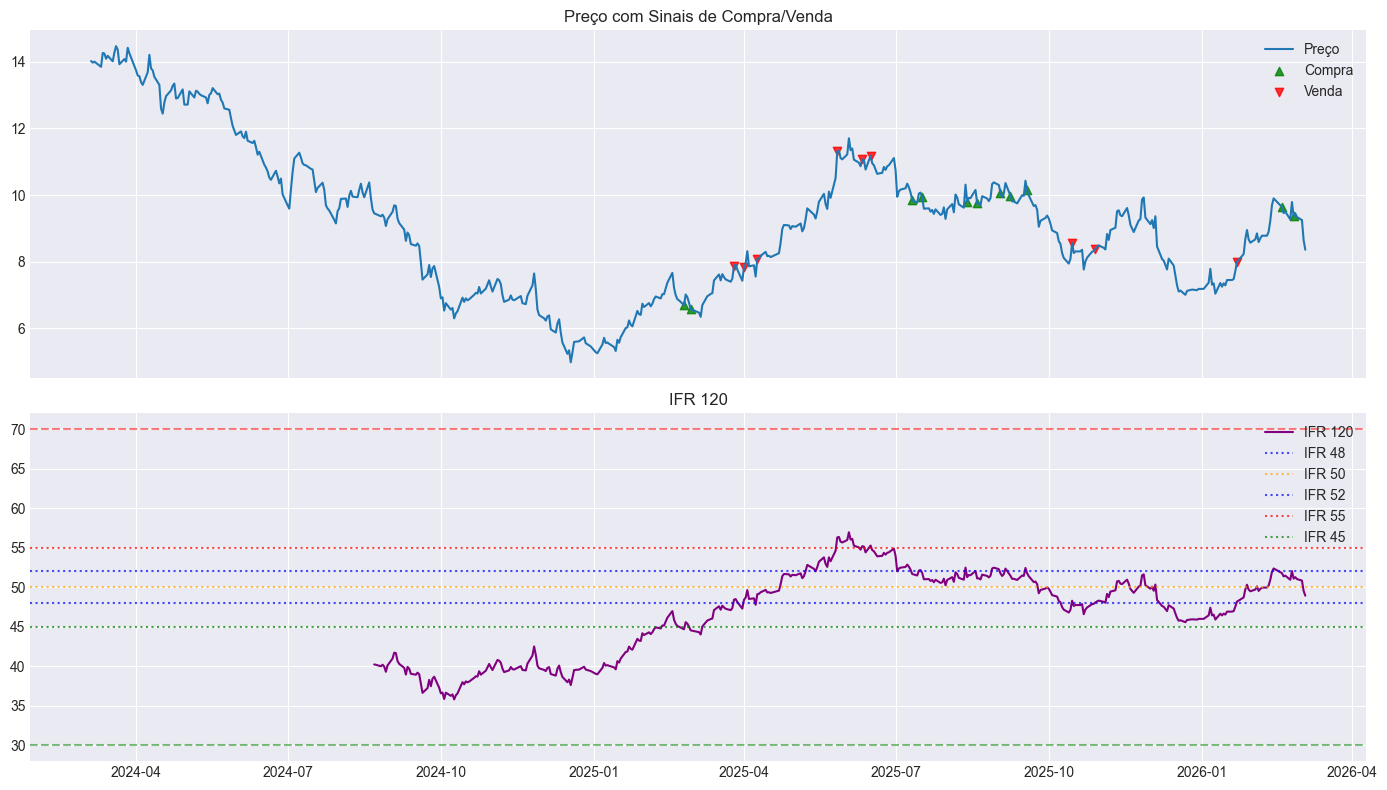

In [65]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14,8), sharex=True)

# Preço
ax1.plot(df['close'], label='Preço')
ax1.scatter(df.index[df['sinal_compra']], df['close'][df['sinal_compra']], marker='^', color='g', label='Compra', alpha=0.8)
ax1.scatter(df.index[df['sinal_venda']], df['close'][df['sinal_venda']], marker='v', color='r', label='Venda', alpha=0.8)
ax1.set_title('Preço com Sinais de Compra/Venda')
ax1.legend()

# IFR
ax2.plot(df['rsi_120'], label='IFR 120', color='purple')
ax2.axhline(30, color='g', linestyle='--', alpha=0.5)
ax2.axhline(70, color='r', linestyle='--', alpha=0.5)
# Linhas horizontais extras para 48, 50, 52
ax2.axhline(48, color='blue', linestyle=':', alpha=0.7, label='IFR 48')
ax2.axhline(50, color='orange', linestyle=':', alpha=0.7, label='IFR 50')
ax2.axhline(52, color='blue', linestyle=':', alpha=0.7, label='IFR 52')
ax2.axhline(55, color='red', linestyle=':', alpha=0.7, label='IFR 55')
ax2.axhline(45, color='green', linestyle=':', alpha=0.7, label='IFR 45')
ax2.set_title('IFR 120')
ax2.legend()

plt.tight_layout()
plt.show()

## 6. Backtest da Estratégia

Simulação simples de compra/venda baseada nos sinais do IFR 120:

In [66]:
# Backtest com stop e alvo por IFR (refatorado):
import numpy as np
capital = 1_000.0
position = 0.0
cash = capital
returns = []
in_trade = False
trade_entry_price = None
trade_type = None  # 'compra' ou 'venda'
entrada_45 = False  # Flag para saber se a entrada foi pelo 45
entrada_55 = False  # Flag para saber se a entrada foi pelo 55

# Garante que o DataFrame df está definido
try:
    df
except NameError:
    raise RuntimeError("O DataFrame 'df' não está definido. Execute a célula de carregamento de dados antes do backtest.")

for idx, row in df.iterrows():
    # Entrada de compra: pullback OU cruzou 45 para baixo
    if row['sinal_compra'] and not in_trade and cash > 0:
        position = cash / row['close']
        cash = 0
        in_trade = True
        trade_entry_price = row['close']
        trade_type = 'compra'
        entrada_45 = (row['rsi_120'] <= 45) and (df['rsi_120'].shift(1).loc[idx] > 45)
        continue
    # Entrada de venda: pullback OU cruzou 55 para cima
    if row['sinal_venda'] and not in_trade and position > 0:
        cash = position * row['close']
        returns.append((row['close'] - trade_entry_price) / trade_entry_price)
        position = 0
        in_trade = True
        trade_entry_price = row['close']
        trade_type = 'venda'
        entrada_55 = (row['rsi_120'] >= 55) and (df['rsi_120'].shift(1).loc[idx] < 55)
        continue
    # Saída por alvo ou stop de IFR
    if in_trade:
        if trade_type == 'compra':
            # Stop em 48 se entrou pelo 45, senão stop em 50, alvo em 55
            if entrada_45:
                if row['rsi_120'] >= 55 or row['rsi_120'] >= 48:
                    cash = position * row['close']
                    returns.append((row['close'] - trade_entry_price) / trade_entry_price)
                    position = 0
                    in_trade = False
                    trade_entry_price = None
                    trade_type = None
                    entrada_45 = False
            else:
                if row['rsi_120'] >= 55 or row['rsi_120'] >= 50:
                    cash = position * row['close']
                    returns.append((row['close'] - trade_entry_price) / trade_entry_price)
                    position = 0
                    in_trade = False
                    trade_entry_price = None
                    trade_type = None
        elif trade_type == 'venda':
            # Stop em 52 se entrou pelo 55, senão stop em 50, alvo em 45
            if entrada_55:
                if row['rsi_120'] <= 45 or row['rsi_120'] <= 52:
                    cash = position * row['close'] if position > 0 else cash
                    if position > 0:
                        returns.append((row['close'] - trade_entry_price) / trade_entry_price)
                    position = 0
                    in_trade = False
                    trade_entry_price = None
                    trade_type = None
                    entrada_55 = False
            else:
                if row['rsi_120'] <= 45 or row['rsi_120'] <= 50:
                    cash = position * row['close'] if position > 0 else cash
                    if position > 0:
                        returns.append((row['close'] - trade_entry_price) / trade_entry_price)
                    position = 0
                    in_trade = False
                    trade_entry_price = None
                    trade_type = None

# Valor final
final_value = cash + position * df['close'].iloc[-1]
print(f"Retorno final: {final_value/capital - 1:.2%}")

# Retornos das operações
if returns:
    print(f"Retorno médio por trade: {np.mean(returns):.2%}")
else:
    print("Nenhum trade executado.")

Retorno final: 7.94%
Retorno médio por trade: 0.92%


## 7. Avaliação de Performance

Cálculo de métricas como retorno acumulado, drawdown e índice de Sharpe:

Sharpe (buy & hold): -0.36
Drawdown máximo: -65.57%


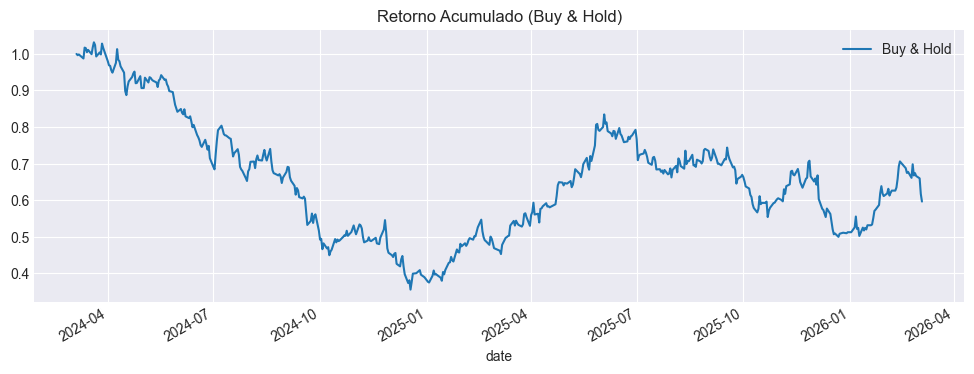

In [67]:
# Retorno acumulado diário (buy & hold para comparação)
df['retorno_diario'] = df['close'].pct_change().fillna(0)
df['retorno_acumulado'] = (1 + df['retorno_diario']).cumprod()

# Drawdown
df['max_acum'] = df['retorno_acumulado'].cummax()
df['drawdown'] = df['retorno_acumulado'] / df['max_acum'] - 1

# Sharpe (simples, sem ajuste de risco)
sharpe = df['retorno_diario'].mean() / df['retorno_diario'].std() * np.sqrt(252)

print(f"Sharpe (buy & hold): {sharpe:.2f}")
print(f"Drawdown máximo: {df['drawdown'].min():.2%}")

plt.figure(figsize=(12,4))
df['retorno_acumulado'].plot(label='Buy & Hold')
plt.title('Retorno Acumulado (Buy & Hold)')
plt.legend()
plt.show()

## 8. Teste de Teorias: IFR 120 como Retorno à Média e Sinais de Exaustão


Nesta seção, analisamos eventos em que o IFR 120 repousa entre 52 e 48 (potencial pullback), e também o comportamento após cruzamentos dos níveis 60 e 50.


**Teoria aplicada:**


- Níveis 60, 55, 45, 40 são zonas de exaustão, não de entrada de tendência.
- Cruzar 60 para cima: geralmente exaustão, NÃO esperar alta. Pode indicar reversão ou lateralização.
- Cruzar 60 para baixo: fraqueza, pode esperar baixa.
- Cruzar 50 para cima: início de força, pode esperar alta.
- Cruzar 50 para baixo: início de fraqueza, pode esperar baixa.
- Pullbacks na faixa 48-52: podem sinalizar retomada de tendência, dependendo da direção de onde veio o IFR.


Os resultados abaixo mostram as probabilidades de alta/baixa após cada evento, mas a interpretação deve seguir a teoria acima.

In [70]:
# 1. Pullback de Alta e de Baixa na faixa 48-52 do IFR 120
"""
Pullbacks na faixa 48-52:
- Pullback de alta: IFR entra na faixa 48-52 vindo de cima (>52 → 48-52). Sinaliza pausa em tendência de alta, não necessariamente continuação da alta.
- Pullback de baixa: IFR entra na faixa 48-52 vindo de baixo (<48 → 48-52). Sinaliza pausa em tendência de baixa, não necessariamente reversão.
Atenção: não são sinais de reversão, mas de pausa/repouso na tendência. O retorno médio mostra o comportamento típico após esses eventos.
"""

mask_repouso = (df['rsi_120'] <= 52) & (df['rsi_120'] >= 48)
mask_antes_cima = df['rsi_120'].shift(1) > 52
mask_antes_baixo = df['rsi_120'].shift(1) < 48

pullback_alta = mask_repouso & mask_antes_cima  # Pullback de alta
pullback_baixa = mask_repouso & mask_antes_baixo  # Pullback de baixa

# Função para calcular retorno médio após N dias
def retorno_medio(indices, dias):
    retornos = []
    for idx in df[indices].index:
        pos = df.index.get_loc(idx)
        if pos + dias < len(df):
            ret = (df.iloc[pos+dias]['close'] - df.iloc[pos]['close']) / df.iloc[pos]['close']
            retornos.append(ret)
    return np.mean(retornos) if retornos else float('nan')

for dias in [5, 10, 15]:
    ret_alta = retorno_medio(pullback_alta, dias)
    ret_baixa = retorno_medio(pullback_baixa, dias)
    print(f'--- Pullbacks IFR 120 (faixa 48-52) - Retorno médio após {dias} dias ---')
    print(f'Qtd de pullbacks de alta (>52→48-52): {pullback_alta.sum()}')
    print(f'Retorno médio {dias} dias após pullback de alta: {ret_alta:.2%}')
    print(f'Qtd de pullbacks de baixa (<48→48-52): {pullback_baixa.sum()}')
    print(f'Retorno médio {dias} dias após pullback de baixa: {ret_baixa:.2%}')
    print('Obs: Retornos positivos ou negativos indicam se há tendência de continuidade, reversão ou lateralização após o pullback.')
    print()

--- Pullbacks IFR 120 (faixa 48-52) - Retorno médio após 5 dias ---
Qtd de pullbacks de alta (>52→48-52): 9
Retorno médio 5 dias após pullback de alta: -3.80%
Qtd de pullbacks de baixa (<48→48-52): 6
Retorno médio 5 dias após pullback de baixa: 0.46%
Obs: Retornos positivos ou negativos indicam se há tendência de continuidade, reversão ou lateralização após o pullback.

--- Pullbacks IFR 120 (faixa 48-52) - Retorno médio após 10 dias ---
Qtd de pullbacks de alta (>52→48-52): 9
Retorno médio 10 dias após pullback de alta: -4.01%
Qtd de pullbacks de baixa (<48→48-52): 6
Retorno médio 10 dias após pullback de baixa: 6.63%
Obs: Retornos positivos ou negativos indicam se há tendência de continuidade, reversão ou lateralização após o pullback.

--- Pullbacks IFR 120 (faixa 48-52) - Retorno médio após 15 dias ---
Qtd de pullbacks de alta (>52→48-52): 9
Retorno médio 15 dias após pullback de alta: -4.25%
Qtd de pullbacks de baixa (<48→48-52): 6
Retorno médio 15 dias após pullback de baixa: 10.

In [69]:
# 2. Eventos de exaustão: IFR cruza 60 ou 50 de baixo para cima e de cima para baixo
"""
Interpretação dos cruzamentos:
- Cruzar 60 para cima: geralmente exaustão, NÃO esperar alta. Pode indicar reversão ou lateralização.
- Cruzar 60 para baixo: indica fraqueza, pode esperar baixa.
- Cruzar 50 para cima: início de força, pode esperar alta.
- Cruzar 50 para baixo: início de fraqueza, pode esperar baixa.
- Níveis extremos (60, 55, 45, 40): são zonas de exaustão, não de entrada de tendência.
"""

def prob_subida(indices, dias=5):
    subidas = 0
    total = 0
    for idx in df[indices].index:
        pos = df.index.get_loc(idx)
        if pos + dias < len(df):
            ret = (df.iloc[pos+dias]['close'] - df.iloc[pos]['close']) / df.iloc[pos]['close']
            if ret > 0: subidas += 1
            total += 1
    return subidas / total if total > 0 else np.nan

def prob_baixa(indices, dias=5):
    baixas = 0
    total = 0
    for idx in df[indices].index:
        pos = df.index.get_loc(idx)
        if pos + dias < len(df):
            ret = (df.iloc[pos+dias]['close'] - df.iloc[pos]['close']) / df.iloc[pos]['close']
            if ret < 0: baixas += 1
            total += 1
    return baixas / total if total > 0 else np.nan

eventos_60_up = (df['rsi_120'] >= 60) & (df['rsi_120'].shift(1) < 60)
eventos_60_down = (df['rsi_120'] <= 60) & (df['rsi_120'].shift(1) > 60)
eventos_50_up = (df['rsi_120'] >= 50) & (df['rsi_120'].shift(1) < 50)
eventos_50_down = (df['rsi_120'] <= 50) & (df['rsi_120'].shift(1) > 50)

print('--- Interpretação dos cruzamentos ---')
print('Cruzou 60 para cima: exaustão, NÃO esperar alta!')
print('Cruzou 60 para baixo: fraqueza, pode esperar baixa.')
print('Cruzou 50 para cima: início de força, pode esperar alta.')
print('Cruzou 50 para baixo: início de fraqueza, pode esperar baixa.')
print()

print(f'Qtd eventos cruzou 60 para cima: {eventos_60_up.sum()}')
print(f'Prob. de alta 5 dias após cruzar 60 para cima (exaustão): {prob_subida(eventos_60_up):.2%}')
print(f'Prob. de baixa 5 dias após cruzar 60 para cima: {prob_baixa(eventos_60_up):.2%}')
print()
print(f'Qtd eventos cruzou 60 para baixo: {eventos_60_down.sum()}')
print(f'Prob. de alta 5 dias após cruzar 60 para baixo: {prob_subida(eventos_60_down):.2%}')
print(f'Prob. de baixa 5 dias após cruzar 60 para baixo (fraqueza): {prob_baixa(eventos_60_down):.2%}')
print()
print(f'Qtd eventos cruzou 50 para cima: {eventos_50_up.sum()}')
print(f'Prob. de alta 5 dias após cruzar 50 para cima (força): {prob_subida(eventos_50_up):.2%}')
print(f'Prob. de baixa 5 dias após cruzar 50 para cima: {prob_baixa(eventos_50_up):.2%}')
print()
print(f'Qtd eventos cruzou 50 para baixo: {eventos_50_down.sum()}')
print(f'Prob. de alta 5 dias após cruzar 50 para baixo: {prob_subida(eventos_50_down):.2%}')
print(f'Prob. de baixa 5 dias após cruzar 50 para baixo (fraqueza): {prob_baixa(eventos_50_down):.2%}')

--- Interpretação dos cruzamentos ---
Cruzou 60 para cima: exaustão, NÃO esperar alta!
Cruzou 60 para baixo: fraqueza, pode esperar baixa.
Cruzou 50 para cima: início de força, pode esperar alta.
Cruzou 50 para baixo: início de fraqueza, pode esperar baixa.

Qtd eventos cruzou 60 para cima: 0
Prob. de alta 5 dias após cruzar 60 para cima (exaustão): nan%
Prob. de baixa 5 dias após cruzar 60 para cima: nan%

Qtd eventos cruzou 60 para baixo: 0
Prob. de alta 5 dias após cruzar 60 para baixo: nan%
Prob. de baixa 5 dias após cruzar 60 para baixo (fraqueza): nan%

Qtd eventos cruzou 50 para cima: 9
Prob. de alta 5 dias após cruzar 50 para cima (força): 33.33%
Prob. de baixa 5 dias após cruzar 50 para cima: 66.67%

Qtd eventos cruzou 50 para baixo: 9
Prob. de alta 5 dias após cruzar 50 para baixo: 50.00%
Prob. de baixa 5 dias após cruzar 50 para baixo (fraqueza): 50.00%


In [53]:
# Verifica o range de datas de todos os arquivos de features locais
import glob
import pandas as pd
import os

# Caminho dos arquivos de features
features_path = '../../co-piloto-quant/src/co_piloto_quant/data/features/'
arquivos = glob.glob(os.path.join(features_path, '*_enriched.parquet'))
print(f"Total de arquivos encontrados: {len(arquivos)}")
for arquivo in arquivos:
    try:
        df = pd.read_parquet(arquivo)
        if 'close' in df.columns:
            data_min = df.index.min() if df.index.name in ['date', None] else df['date'].min()
            data_max = df.index.max() if df.index.name in ['date', None] else df['date'].max()
            print(f"{os.path.basename(arquivo)}: {data_min} até {data_max} ({len(df)})")
        else:
            print(f"{os.path.basename(arquivo)}: coluna 'close' não encontrada.")
    except Exception as e:
        print(f"Erro ao ler {arquivo}: {e}")

Total de arquivos encontrados: 69
ABEV3_SA_enriched.parquet: 2024-03-05 00:00:00 até 2026-03-04 00:00:00 (500)
ALOS3_SA_enriched.parquet: 2024-03-05 00:00:00 até 2026-03-04 00:00:00 (499)
ASAI3_SA_enriched.parquet: 2024-03-05 00:00:00 até 2026-03-04 00:00:00 (500)
AURE3_SA_enriched.parquet: 2024-03-05 00:00:00 até 2026-03-04 00:00:00 (500)
B3SA3_SA_enriched.parquet: 2024-03-05 00:00:00 até 2026-03-04 00:00:00 (500)
BBAS3_SA_enriched.parquet: 2024-03-05 00:00:00 até 2026-03-04 00:00:00 (499)
BBDC3_SA_enriched.parquet: 2024-03-05 00:00:00 até 2026-03-04 00:00:00 (500)
BBDC4_SA_enriched.parquet: 2024-03-05 00:00:00 até 2026-03-04 00:00:00 (500)
BBSE3_SA_enriched.parquet: 2024-03-05 00:00:00 até 2026-03-04 00:00:00 (500)
BEEF3_SA_enriched.parquet: 2024-03-05 00:00:00 até 2026-03-04 00:00:00 (500)
BPAC11_SA_enriched.parquet: 2024-03-05 00:00:00 até 2026-03-04 00:00:00 (500)
BRAP4_SA_enriched.parquet: 2024-03-05 00:00:00 até 2026-03-04 00:00:00 (500)
BRKM5_SA_enriched.parquet: 2024-03-05 00:

## Dica profissional: Como filtrar apenas linhas válidas para indicadores derivados

Ao analisar ou treinar modelos, use o seguinte padrão para garantir que só utiliza linhas onde o indicador desejado não é NaN, mas preservando todo o histórico de preços no arquivo original.

Exemplo para o IFR 120:

In [ ]:
# Filtra apenas linhas onde o indicador desejado não é NaN (exemplo: IFR 120)
df_valid = df.dropna(subset=['rsi_120'])
print(f"Linhas válidas para IFR 120: {len(df_valid)} de {len(df)} totais")
display(df_valid[['close', 'rsi_120']].head())

---

### Nota sobre as novas regras de entrada e stop

- **Entradas adicionais:**
    - Compra ao cruzar IFR 45 para baixo (além do pullback 48-52).
    - Venda ao cruzar IFR 55 para cima (além do pullback 48-52).
- **Stop das novas entradas:**
    - Para compras por 45, o stop é IFR cruzando 50 para cima.
    - Para vendas por 55, o stop é IFR cruzando 50 para baixo.
- **Alvos:**
    - Para compras, alvo em IFR 55.
    - Para vendas, alvo em IFR 45.

Essas regras tornam a estratégia mais responsiva a exaustões, buscando reversões rápidas a partir dos extremos do IFR 120.

> **Dica:** Ajuste os níveis conforme o ativo e o perfil de volatilidade. Sempre valide os resultados com backtest antes de operar ao vivo.

> **Atualização das regras de stop:**
>
> - **Compra pelo 45:** stop agora é IFR cruzando 48 para baixo (antes era 50).
> - **Venda pelo 55:** stop agora é IFR cruzando 52 para cima (antes era 50).
>
> As demais regras permanecem iguais. Isso torna o stop mais ajustado ao ponto de entrada por exaustão.